# Equilibrio elástico: sólidos en reposo

El punto de partida es una afirmación física muy sencilla: si un sólido está en reposo, las fuerzas que actúan sobre cada pequeña región deben estar equilibradas.

En mecánica del continuo, esa afirmación se escribe como una ecuación diferencial:

$$
\nabla\cdot\boldsymbol{\sigma}
+
\rho\,\vec{g}
=
\vec{0}.
$$

Aquí $\boldsymbol{\sigma}$ es el tensor de esfuerzos, $\rho\,\vec{g}$ es la fuerza de cuerpo por unidad de volumen y $\nabla\cdot\boldsymbol{\sigma}$ reúne cómo cambian los esfuerzos de un punto a otro.

En un problema muy sencillo podemos integrar esta ecuación y obtener una solución analítica. Pero, ¿qué hacemos cuando la geometría, las fronteras o el material son más complicados?

La pregunta de este notebook es:

> ¿Cómo pasamos de esta ecuación diferencial a una solución numérica aproximada sobre una malla?

Para responderla construiremos, paso a paso, una cadena de ideas:

$$
\text{desplazamientos}
\longrightarrow
\text{deformaciones}
\longrightarrow
\text{esfuerzos}
\longrightarrow
\text{residuo de equilibrio}.
$$

La solución numérica será un campo de desplazamientos que haga pequeño ese residuo y respete las condiciones de frontera.

## 1. Un ejemplo sencillo en dos dimensiones

Consideremos un bloque rectangular de ancho $a$ y altura $b$:

$$
0\leq x\leq a,
\qquad
0\leq y\leq b.
$$

Trabajaremos en dos dimensiones y tomaremos el eje $y$ apuntando hacia arriba. La gravedad apunta hacia abajo, por lo que

$$
\vec{g}=-g\,\hat{\mathbf{y}},
\qquad
g>0.
$$

Por ahora imaginemos que el bloque está contenido lateralmente y apoyado en su base:

- en las paredes laterales no puede abrirse horizontalmente:
  $u_x(0,y)=0$ y $u_x(a,y)=0$;
- en la base no puede desplazarse verticalmente:
  $u_y(x,0)=0$;
- la superficie superior está libre: allí no imponemos un desplazamiento, sino una tracción aproximadamente nula.

Esta distinción será importante: una frontera puede decirnos directamente cuánto vale un desplazamiento, o puede decirnos qué fuerza debe transmitir.

Antes de buscar la solución, necesitamos un punto de partida numérico. Usaremos inicialmente el campo

$$
u_x^{(0)}(x,y)=0,
\qquad
u_y^{(0)}(x,y)=0.
$$

Este campo inicial no es todavía la solución física; es solo nuestra primera propuesta.

In [51]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.figsize': (6.5, 4.5),
    'axes.grid': True,
    'grid.alpha': 0.25,
})

In [52]:
# Parámetros sencillos del ejemplo.
a, b = 1.0, 1.0
E = 2.0
nu = 1 / 3
g = 1.0
rho = 1.0
rho_g = rho * g

# La gravedad apunta hacia abajo: f_y = -rho_g.
n = 21
omega = 1.0
nsteps = 2500
visual_scale = 1.5

x = np.linspace(0.0, a, n)
y = np.linspace(0.0, b, n)
X, Y = np.meshgrid(x, y)
dx = x[1] - x[0]
dy = y[1] - y[0]

print(f'paso horizontal dx = {dx:.3f}')
print(f'paso vertical dy = {dy:.3f}')
print(f'gravedad: g_vec = -{g:.1f} y_hat')

paso horizontal dx = 0.050
paso vertical dy = 0.050
gravedad: g_vec = -1.0 y_hat


## 2. La malla: representar un campo continuo con arreglos

Una computadora no almacena $u_x(x,y)$ y $u_y(x,y)$ en todos los puntos del continuo. Los aproxima en un conjunto finito de nodos.

En esta malla:

- X[i, j] y Y[i, j] guardan la posición del nodo;
- UX[i, j] y UY[i, j] guardarán sus desplazamientos;
- la fila i=0 corresponde a la base $y=0$;
- la columna j=0 corresponde a la pared izquierda $x=0$;
- la columna j=-1 corresponde a la pared derecha $x=a$;
- entre cuatro nodos vecinos aparece un elemento cuadrilateral.

La figura no es solo decorativa: nos permite verificar qué fila o columna representa cada frontera antes de escribir código.

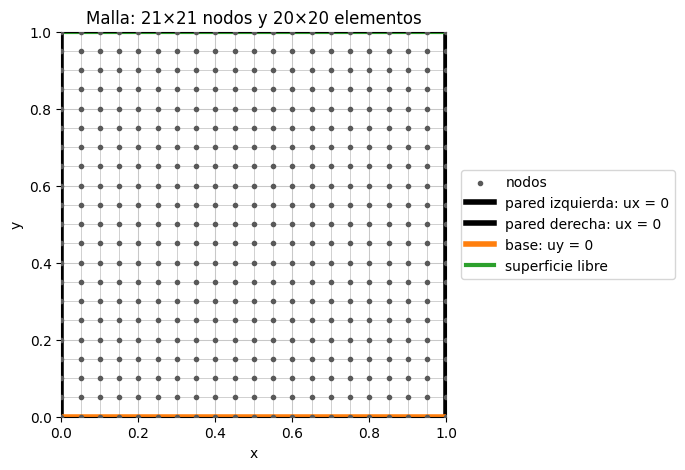

nodos totales = 441
elementos cuadriláteros = 400


In [53]:
fig, ax = plt.subplots(figsize=(5.5, 5))

# Cada cuadrícula dibujada corresponde a los bordes de un elemento.
ax.pcolormesh(
    X, Y, np.zeros((n - 1, n - 1)),
    shading='flat',
    edgecolors='0.82',
    facecolors='none',
    linewidth=0.5
)

# Los puntos muestran los nodos donde almacenaremos UX y UY.
ax.scatter(X, Y, s=9, color='0.35', zorder=3, label='nodos')

# Colores y etiquetas para identificar las fronteras.
ax.plot(X[:, 0], Y[:, 0], 'k-', lw=4, label='pared izquierda: ux = 0')
ax.plot(X[:, -1], Y[:, -1], 'k-', lw=4, label='pared derecha: ux = 0')
ax.plot(X[0, :], Y[0, :], color='tab:orange', lw=4, label='base: uy = 0')
ax.plot(X[-1, :], Y[-1, :], color='tab:green', lw=3, label='superficie libre')

ax.set(
    xlabel='x',
    ylabel='y',
    title=f'Malla: {n}×{n} nodos y {(n - 1)}×{(n - 1)} elementos'
)
ax.set_aspect('equal')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.show()

print(f'nodos totales = {n * n}')
print(f'elementos cuadriláteros = {(n - 1) * (n - 1)}')

### Reto 1 — convertir fronteras físicas en índices

Ahora usa la figura y los nombres de los arreglos para escribir las tres condiciones de desplazamiento:

1. todos los nodos de la pared izquierda deben tener $u_x=0$;
2. todos los nodos de la pared derecha deben tener $u_x=0$;
3. todos los nodos de la base deben tener $u_y=0$.

Crea dos arreglos de prueba llenos de unos y escribe las asignaciones que los conviertan en compatibles con los apoyos.

Pista de lectura de índices:

- dos puntos significa “todos los índices de esa dirección”;
- [:, 0] significa “todas las filas de la primera columna”;
- [:, -1] significa “todas las filas de la última columna”;
- [0, :] significa “la primera fila completa”.

La superficie superior no aparece en estas tres asignaciones: allí no fijamos UX ni UY.

In [54]:
# Solución del Reto 1.
# Esta celda puede ocultarse para intentar primero el reto.
UX_reto = np.ones_like(X)
UY_reto = np.ones_like(Y)

# Pared izquierda: todas las filas de la columna 0.
UX_reto[:, 0] = 0.0

# Pared derecha: todas las filas de la última columna.
UX_reto[:, -1] = 0.0

# Base: todas las columnas de la fila 0.
UY_reto[0, :] = 0.0

print('UX en la pared izquierda:', np.unique(UX_reto[:, 0]))
print('UX en la pared derecha:', np.unique(UX_reto[:, -1]))
print('UY en la base:', np.unique(UY_reto[0, :]))

UX en la pared izquierda: [0.]
UX en la pared derecha: [0.]
UY en la base: [0.]


### De las asignaciones a una función

Las tres asignaciones anteriores se repetirán muchas veces durante la relajación. Por eso las agrupamos en una función.

La función recibe un campo provisional y devuelve una copia compatible con los apoyos. Usamos .copy() para no modificar silenciosamente el arreglo que recibió: así podemos comparar el campo antes y después de imponer las fronteras.

In [55]:
def imponer_apoyos(UX, UY):
    """Fija los desplazamientos prescritos en las fronteras apoyadas."""
    UX_apoyado = UX.copy()
    UY_apoyado = UY.copy()

    # Pared izquierda: UX[:, 0] recorre todas sus filas.
    UX_apoyado[:, 0] = 0.0

    # Pared derecha: UX[:, -1] recorre todas sus filas.
    UX_apoyado[:, -1] = 0.0

    # Base: UY[0, :] recorre todas sus columnas.
    UY_apoyado[0, :] = 0.0

    return UX_apoyado, UY_apoyado

In [56]:
# Primero comprobamos la función con un campo que no respeta los apoyos.
UX_prueba = 0.1 * np.ones_like(X)
UY_prueba = 0.1 * np.ones_like(Y)

UX_corregido, UY_corregido = imponer_apoyos(UX_prueba, UY_prueba)

print('máximo UX antes en las paredes:',
      max(np.max(np.abs(UX_prueba[:, 0])), np.max(np.abs(UX_prueba[:, -1]))))
print('máximo UX después en las paredes:',
      max(np.max(np.abs(UX_corregido[:, 0])), np.max(np.abs(UX_corregido[:, -1]))))
print('máximo UY después en la base:',
      np.max(np.abs(UY_corregido[0, :])))

# Este es el campo inicial real del cálculo: desplazamiento nulo en todo el bloque.
UX = np.zeros_like(X)
UY = np.zeros_like(Y)
UX, UY = imponer_apoyos(UX, UY)

print('máximo desplazamiento inicial:', np.max(np.abs([UX, UY])))

máximo UX antes en las paredes: 0.1
máximo UX después en las paredes: 0.0
máximo UY después en la base: 0.0
máximo desplazamiento inicial: 0.0


## 3. Del campo discreto a las derivadas

Ya tenemos un lugar donde guardar los desplazamientos, pero todavía necesitamos calcular qué significan físicamente.

A partir de un campo $F(x,y)$ queremos estimar cuánto cambia al movernos una distancia pequeña:

$$
\frac{\partial F}{\partial x},
\qquad
\frac{\partial F}{\partial y}.
$$

En la malla, np.gradient usa los valores vecinos para aproximar esas derivadas. Antes de usarla en el sólido, la probamos con campos cuya respuesta conocemos exactamente.

In [57]:
def gradientes(F, dx, dy):
    # Las filas de una matriz avanzan en la dirección y.
    # Las columnas avanzan en la dirección x.
    dF_dy, dF_dx = np.gradient(F, dy, dx, edge_order=2)
    return dF_dx, dF_dy

# Para estos campos conocemos las derivadas:
# d(2x + 3y)/dx = 2,   d(2x + 3y)/dy = 3
# d(-x + 4y)/dx = -1,  d(-x + 4y)/dy = 4
UX_test = 2 * X + 3 * Y
UY_test = -X + 4 * Y

dUX_dx, dUX_dy = gradientes(UX_test, dx, dy)
dUY_dx, dUY_dy = gradientes(UY_test, dx, dy)

print('error en dUX/dx:', np.max(np.abs(dUX_dx - 2)))
print('error en dUX/dy:', np.max(np.abs(dUX_dy - 3)))
print('error en dUY/dx:', np.max(np.abs(dUY_dx + 1)))
print('error en dUY/dy:', np.max(np.abs(dUY_dy - 4)))

error en dUX/dx: 2.842170943040401e-14
error en dUX/dy: 2.842170943040401e-14
error en dUY/dx: 1.4210854715202004e-14
error en dUY/dy: 2.842170943040401e-14


## 4. Deformación: cómo cambia la forma del sólido

El desplazamiento nos dice cuánto se mueve un punto. La deformación nos dice cómo cambia la separación entre puntos vecinos.

En pequeñas deformaciones:

$$
\varepsilon_{xx}=\frac{\partial u_x}{\partial x},
\qquad
\varepsilon_{yy}=\frac{\partial u_y}{\partial y},
$$

$$
\varepsilon_{xy}
=
\frac{1}{2}
\left(
\frac{\partial u_x}{\partial y}
+
\frac{\partial u_y}{\partial x}
\right).
$$

Estas tres cantidades son las que pasaremos a la ley constitutiva del material.

In [58]:
def deformacion(UX, UY, dx, dy):
    dUX_dx, dUX_dy = gradientes(UX, dx, dy)
    dUY_dx, dUY_dy = gradientes(UY, dx, dy)

    epsilon_xx = dUX_dx
    epsilon_yy = dUY_dy
    epsilon_xy = 0.5 * (dUX_dy + dUY_dx)

    return epsilon_xx, epsilon_yy, epsilon_xy

# El campo inicial es constante y nulo, así que su deformación también es nula.
UXX, UYY, UXY = deformacion(UX, UY, dx, dy)
print('máxima deformación inicial:',
      np.max(np.abs([UXX, UYY, UXY])))

máxima deformación inicial: 0.0


## 5. Esfuerzo: relacionar deformación y material

Ahora necesitamos una relación entre deformación y esfuerzo. Para un material elástico lineal e isótropo usamos la ley de Hooke en deformación plana:

$$
\boldsymbol{\sigma}
=
2\mu\,\boldsymbol{\varepsilon}
+
\lambda\,
\operatorname{tr}(\boldsymbol{\varepsilon})\,
\mathbf{I}.
$$

Los parámetros $\lambda$ y $\mu$ dependen del módulo de Young $E$ y del coeficiente de Poisson $\nu$:

$$
\mu=\frac{E}{2(1+\nu)},
\qquad
\lambda=\frac{E\nu}{(1+\nu)(1-2\nu)}.
$$

En componentes:

$$
\sigma_{xx}=2\mu\varepsilon_{xx}
+\lambda(\varepsilon_{xx}+\varepsilon_{yy}),
$$

$$
\sigma_{yy}=2\mu\varepsilon_{yy}
+\lambda(\varepsilon_{xx}+\varepsilon_{yy}),
\qquad
\sigma_{xy}=2\mu\varepsilon_{xy}.
$$

La cadena ya está completa hasta los esfuerzos:

$$
(u_x,u_y)
\longrightarrow
(\varepsilon_{xx},\varepsilon_{yy},\varepsilon_{xy})
\longrightarrow
(\sigma_{xx},\sigma_{yy},\sigma_{xy}).
$$

In [59]:
def parametros_lame(E, nu):
    mu = E / (2.0 * (1.0 + nu))
    lam = E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))
    return lam, mu


def esfuerzo(UX, UY, dx, dy, E, nu):
    lam, mu = parametros_lame(E, nu)
    UXX, UYY, UXY = deformacion(UX, UY, dx, dy)

    traza = UXX + UYY
    SXX = 2.0 * mu * UXX + lam * traza
    SYY = 2.0 * mu * UYY + lam * traza
    SXY = 2.0 * mu * UXY

    return SXX, SYY, SXY


lam, mu = parametros_lame(E, nu)
SXX0, SYY0, SXY0 = esfuerzo(UX, UY, dx, dy, E, nu)

print(f'lambda = {lam:.3f}')
print(f'mu = {mu:.3f}')
print('máximo esfuerzo inicial:',
      np.max(np.abs([SXX0, SYY0, SXY0])))

lambda = 1.500
mu = 0.750
máximo esfuerzo inicial: 0.0


## 6. Proponer un campo y comprobar si está en equilibrio

La computadora no conoce de antemano el campo correcto. Primero proponemos uno —por ahora, el campo nulo— y luego preguntamos qué tan bien satisface la ecuación de equilibrio.

La lógica es:

1. proponemos $\mathbf{u}$;
2. calculamos sus derivadas;
3. obtenemos $\boldsymbol{\varepsilon}$;
4. calculamos $\boldsymbol{\sigma}$;
5. evaluamos la ecuación de equilibrio.

Con el campo inicial nulo ocurre algo instructivo:

$$
\mathbf{u}^{(0)}=\mathbf{0}
\Longrightarrow
\boldsymbol{\varepsilon}^{(0)}=\mathbf{0}
\Longrightarrow
\boldsymbol{\sigma}^{(0)}=\mathbf{0}.
$$

Pero la gravedad sigue actuando. Por eso ese campo no puede ser todavía la solución: falta un esfuerzo vertical que sostenga el peso del bloque.

### Una referencia analítica para saber qué esperamos

Antes de relajar la malla 2D, podemos resolver un caso simplificado. Supongamos que el desplazamiento solo depende de $y$:

$$
\mathbf{u}(y)=\big(0,u_y(y)\big).
$$

La ecuación vertical de equilibrio se reduce a

$$
-\rho g+\frac{d\sigma_{yy}}{dy}=0.
$$

Como en este caso

$$
\sigma_{yy}=(\lambda+2\mu)\frac{du_y}{dy},
$$

y usamos $u_y(0)=0$ junto con una superficie superior libre, $\sigma_{yy}(b)=0$, obtenemos

$$
D=\frac{\lambda+2\mu}{\rho g},
\qquad
u_y^{\mathrm{analítica}}(y)
=
-\frac{by-y^2/2}{D}.
$$

Esta curva no reemplaza el cálculo numérico: nos sirve como referencia para preguntar cuánto se acerca la aproximación a un caso que sí podemos resolver a mano.

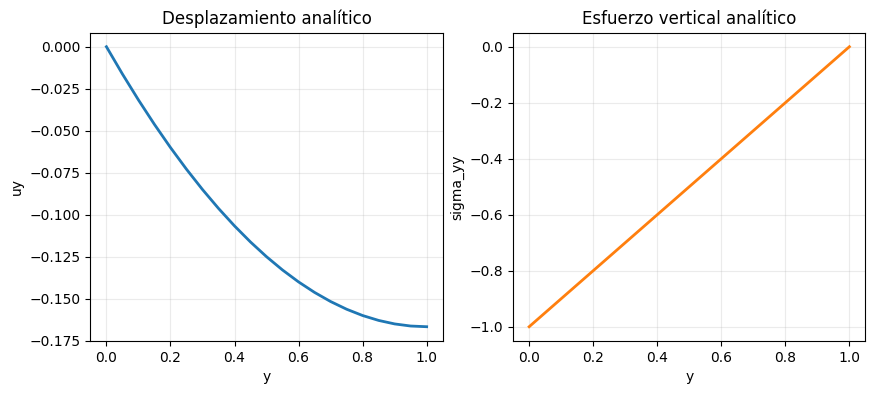

D = 3.000
uy(b) = -0.167


In [60]:
D_analitico = (lam + 2 * mu) / rho_g
uy_analitico = -(b * y - 0.5 * y ** 2) / D_analitico
sigma_yy_analitico = -rho_g * (b - y)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(y, uy_analitico, color='tab:blue', lw=2)
axes[0].set(xlabel='y', ylabel='uy', title='Desplazamiento analítico')

axes[1].plot(y, sigma_yy_analitico, color='tab:orange', lw=2)
axes[1].set(xlabel='y', ylabel='sigma_yy', title='Esfuerzo vertical analítico')

plt.show()

print(f'D = {D_analitico:.3f}')
print(f'uy(b) = {uy_analitico[-1]:.3f}')

## 7. De la ley de Hooke al equilibrio: el residuo

Hasta ahora hemos construido la cadena

$$
\mathbf u
\longrightarrow
\boldsymbol{\varepsilon}(\mathbf u)
\longrightarrow
\boldsymbol{\sigma}(\boldsymbol{\varepsilon}).
$$

Es decir: proponemos un campo de desplazamientos, calculamos las deformaciones y usamos la ley de Hooke para obtener los esfuerzos.

Pero la ley de Hooke, por sí sola, no garantiza que el sólido esté en reposo. La ley de Hooke relaciona esfuerzos y deformaciones; el equilibrio exige además que las fuerzas se compensen localmente:

$$
\nabla\cdot\boldsymbol{\sigma}+\mathbf f=\mathbf 0.
$$

Aquí $\mathbf f$ es la fuerza de cuerpo por unidad de volumen. Para la gravedad de este ejemplo,

$$
\mathbf f=\rho\mathbf g=-\rho g\,\hat{\mathbf y},
\qquad
f_x=0,
\qquad
f_y=-\rho g.
$$

### ¿Qué pasa con una propuesta computacional?

El campo $\mathbf u$ que tenemos en cada momento es solo una propuesta. A partir de ella calculamos $\boldsymbol{\sigma}$ y preguntamos cuánto se aparta de la ecuación de equilibrio:

$$
\mathbf r
=
\nabla\cdot\boldsymbol{\sigma}+\mathbf f.
$$

Llamamos a $\mathbf r$ el **residuo de equilibrio** o **desequilibrio local**. No estamos diciendo que los esfuerzos deban ser cero: los esfuerzos deben variar de tal manera que su divergencia compense la fuerza de cuerpo.

En dos dimensiones,

$$
r_x=
\frac{\partial\sigma_{xx}}{\partial x}
+
\frac{\partial\sigma_{xy}}{\partial y}
+
f_x,
$$

$$
r_y=
\frac{\partial\sigma_{xy}}{\partial x}
+
\frac{\partial\sigma_{yy}}{\partial y}
+
f_y.
$$

Si $\mathbf r=\mathbf 0$, la propuesta satisface el equilibrio interior. Si $\mathbf r\neq\mathbf 0$, todavía queda una fuerza sin compensar; por eso usamos el residuo para decidir cómo corregir el campo de desplazamientos.

In [61]:
def residuo_equilibrio(UX, UY, dx, dy, E, nu, rho_g):
    # 1. La propuesta de desplazamientos produce deformaciones y esfuerzos.
    SXX, SYY, SXY = esfuerzo(UX, UY, dx, dy, E, nu)

    # 2. Calculamos la divergencia de los esfuerzos.
    dSXX_dx, _ = gradientes(SXX, dx, dy)
    dSXY_dx, dSXY_dy = gradientes(SXY, dx, dy)
    _, dSYY_dy = gradientes(SYY, dx, dy)

    # 3. Sumamos la fuerza de cuerpo de la gravedad: f = (0, -rho_g).
    f_x = 0.0
    f_y = -rho_g

    # 4. Lo que no se cancela es el desequilibrio local: el residuo.
    r_x = dSXX_dx + dSXY_dy + f_x
    r_y = dSXY_dx + dSYY_dy + f_y

    return r_x, r_y


def norma_residuo(RX, RY, escala=1.0):
    # Medimos el residuo solo en el interior de la malla.
    interior = np.s_[1:-1, 1:-1]
    valor = np.sqrt(np.mean(RX[interior] ** 2 + RY[interior] ** 2))
    return valor / escala


RX0, RY0 = residuo_equilibrio(UX, UY, dx, dy, E, nu, rho_g)
chi0 = norma_residuo(RX0, RY0, escala=max(abs(rho_g), 1.0))

print(f'residuo inicial chi = {chi0:.3f}')
print(f'residuo vertical interior = {RY0[n // 2, n // 2]:.3f}')

residuo inicial chi = 1.000
residuo vertical interior = -1.000


El resultado tiene una lectura física directa: al comenzar con desplazamientos y esfuerzos nulos, todavía no hay esfuerzos que puedan compensar la gravedad. Por eso el residuo vertical inicial es aproximadamente $-\rho g$.

Esta primera propuesta está lejos del equilibrio. En las siguientes etapas usaremos el desequilibrio local para proponer una corrección del campo de desplazamientos y volveremos a calcular todo el ciclo:

$$
\mathbf u
\longrightarrow
\boldsymbol{\varepsilon}
\longrightarrow
\boldsymbol{\sigma}
\longrightarrow
\mathbf r
\longrightarrow
\text{corrección de }\mathbf u.
$$

## 8. Cómo el residuo propone una nueva solución

El residuo no es únicamente una medida para hacer una gráfica. Es la fuerza que todavía queda sin equilibrar en cada nodo del campo provisional.

Por ejemplo, si en un nodo obtenemos

$$
r_y<0,
$$

la fuerza de cuerpo hacia abajo todavía domina allí. En este problema esperamos entonces que el siguiente campo tenga un desplazamiento vertical más negativo: el material debe empezar a asentarse.

En este notebook elegimos una regla de relajación sencilla:

$$
u_x^{(k+1)}
=
u_x^{(k)}
+
\varepsilon\,r_x^{(k)},
$$

$$
u_y^{(k+1)}
=
u_y^{(k)}
+
\varepsilon\,r_y^{(k)}.
$$

El parámetro $\varepsilon>0$ convierte el residuo —una fuerza por unidad de volumen— en una corrección de desplazamiento. No es una igualdad constitutiva nueva: es una regla numérica para construir la siguiente propuesta.

- si $\varepsilon$ es demasiado grande, la corrección puede oscilar o volverse inestable;
- si $\varepsilon$ es demasiado pequeño, el campo avanza muy lentamente;
- si $r_x=r_y=0$, la corrección es nula y ya no necesitamos cambiar ese nodo.

Esta es una relajación didáctica. Su papel es mostrar el ciclo proponer → medir → corregir, no reemplazar un solucionador general de elasticidad.

### ¿Por qué aparece la escala de la malla?

No necesitamos memorizar una fórmula completa para entender el tamaño del paso. Basta mirar cómo se aproxima una segunda derivada en un nodo interior:

$$
\left.\frac{\partial^2 u}{\partial x^2}\right|_{i,j}
\approx
\frac{u_{i,j+1}-2u_{i,j}+u_{i,j-1}}{dx^2},
$$

$$
\left.\frac{\partial^2 u}{\partial y^2}\right|_{i,j}
\approx
\frac{u_{i+1,j}-2u_{i,j}+u_{i-1,j}}{dy^2}.
$$

Estos son los valores vecinos que rodean al nodo central. Por eso una variación de $u$ cambia el residuo con una escala aproximada

$$
K_{\mathrm{malla}}
\sim
E\left(\frac{1}{dx^2}+\frac{1}{dy^2}\right).
$$

Si la malla se hace más fina, $dx$ y $dy$ disminuyen y esta rigidez numérica aumenta.

Por eso proponemos

$$
\Delta u
\approx
\frac{\omega}{K_{\mathrm{malla}}}\,r,
\qquad
\varepsilon
=
\frac{\omega}{E}
\frac{dx^2dy^2}{dx^2+dy^2}.
$$

En una frontera no tenemos vecinos a ambos lados. Allí usamos, por ejemplo,

$$
\left.\frac{\partial f}{\partial y}\right|_{N}
\approx
\frac{3f_N-4f_{N-1}+f_{N-2}}{2dy}.
$$

Si conocemos la derivada que exige la condición de tracción, despejamos el valor del borde:

$$
f_N
\approx
\frac{4f_{N-1}-f_{N-2}+2dy\,f'_N}{3}.
$$

Esa es la razón de los factores $4$, $-1$ y $3$ que aparecen en la función de frontera. No son constantes misteriosas: salen de una derivada unilateral de segundo orden.

Esta $\\varepsilon$ no es la diagonal exacta del problema elástico: es una escala didáctica para convertir un residuo en una corrección.

In [62]:
def epsilon_relajacion(E, dx, dy, omega=0.65):
    # Escala aproximada de rigidez asociada a las variaciones de la malla.
    rigidez_malla = E * (1.0 / dx**2 + 1.0 / dy**2)

    # omega reduce el paso para evitar correcciones demasiado grandes.
    return omega / rigidez_malla


epsilon = epsilon_relajacion(E, dx, dy, omega)
i, j = n // 2, n // 2

delta_ux = epsilon * RX0[i, j]
delta_uy = epsilon * RY0[i, j]

print(f'nodo elegido: fila i={i}, columna j={j}')
print(f'epsilon = {epsilon:.3e}')
print(f'campo actual: ux={UX[i, j]:.3e}, uy={UY[i, j]:.3e}')
print(f'residuo: rx={RX0[i, j]:.3e}, ry={RY0[i, j]:.3e}')
print(f'corrección: delta_ux={delta_ux:.3e}, delta_uy={delta_uy:.3e}')
print(f'campo propuesto: ux={UX[i, j] + delta_ux:.3e}, '
      f'uy={UY[i, j] + delta_uy:.3e}')

nodo elegido: fila i=10, columna j=10
epsilon = 6.250e-04
campo actual: ux=0.000e+00, uy=0.000e+00
residuo: rx=0.000e+00, ry=-1.000e+00
corrección: delta_ux=0.000e+00, delta_uy=-6.250e-04
campo propuesto: ux=0.000e+00, uy=-6.250e-04


## 9. Condiciones de frontera: desplazamientos y tracciones

En este problema usamos dos tipos de condición:

- En las paredes y en la base prescribimos desplazamientos: $u_x=0$ en las paredes y $u_y=0$ en el piso.
- En una frontera libre prescribimos la tracción externa, no el desplazamiento.

La tracción general deseada es

$$
\mathbf t_{\mathrm{deseada}}=\mathbf t_{\mathrm{ext}}.
$$

Para la superficie superior no aplicamos ninguna fuerza externa. Por eso, en este caso particular,

$$
\mathbf t_{\mathrm{ext}}=\mathbf 0.
$$

La tracción que produce el campo provisional es

$$
\mathbf t^{(k)}
=
\boldsymbol{\sigma}^{(k)}\mathbf n.
$$

En la superficie superior $\mathbf n=\hat{\mathbf y}$:

$$
\mathbf t^{(k)}_{\mathrm{sup}}
=
\begin{pmatrix}
\sigma_{xy}^{(k)}\\
\sigma_{yy}^{(k)}
\end{pmatrix}.
$$

El error de tracción es

$$
\mathbf e_t^{(k)}
=
\mathbf t_{\mathrm{deseada}}
-
\mathbf t^{(k)}.
$$

Como aquí $\mathbf t_{\mathrm{deseada}}=\mathbf 0$,

$$
\mathbf e_t^{(k)}
=
\mathbf 0-\mathbf t^{(k)}
=
-\mathbf t^{(k)}.
$$

Ese signo menos aparece porque queremos eliminar la tracción que todavía calcula el campo provisional.

Para imponerla numéricamente usamos

$$
\sigma_{xy}=0
\quad\Longrightarrow\quad
\frac{\partial u_x}{\partial y}
=
-\frac{\partial u_y}{\partial x},
$$

$$
\sigma_{yy}=0
\quad\Longrightarrow\quad
\frac{\partial u_y}{\partial y}
=
-\frac{\lambda}{\lambda+2\mu}
\frac{\partial u_x}{\partial x}.
$$

La función siguiente usa estas relaciones y una aproximación unilateral de segundo orden para reconstruir los nodos de frontera. Así, la condición de tracción determina cómo se actualiza la superficie.

En las paredes laterales solo fijamos $u_x$; $u_y$ se ajusta para que $\sigma_{xy}=0$. En la base fijamos $u_y$ y dejamos libre el deslizamiento horizontal.

In [63]:
def corregir_superficie_libre(UX, UY, dx, dy, E, nu):
    lam, mu = parametros_lame(E, nu)
    UX = UX.copy()
    UY = UY.copy()
    coef = lam / (lam + 2.0 * mu)

    dUX_dx, dUX_dy = gradientes(UX, dx, dy)
    dUY_dx, dUY_dy = gradientes(UY, dx, dy)

    # Paredes laterales: ux está prescrito, pero uy es tangencial.
    # sigma_xy = 0 implica uy_x = -ux_y.
    UY[1:-1, 0] = (
        4.0 * UY[1:-1, 1] - UY[1:-1, 2]
        + 2.0 * dx * dUX_dy[1:-1, 0]
    ) / 3.0
    UY[1:-1, -1] = (
        4.0 * UY[1:-1, -2] - UY[1:-1, -3]
        - 2.0 * dx * dUX_dy[1:-1, -1]
    ) / 3.0

    # Superficie superior libre.
    objetivo_ux_y = -dUY_dx[-1, :]
    objetivo_uy_y = -coef * dUX_dx[-1, :]

    # Derivada unilateral de segundo orden en el borde superior.
    UX[-1, :] = (
        4.0 * UX[-2, :] - UX[-3, :]
        + 2.0 * dy * objetivo_ux_y
    ) / 3.0
    UY[-1, :] = (
        4.0 * UY[-2, :] - UY[-3, :]
        + 2.0 * dy * objetivo_uy_y
    ) / 3.0

    # Base: uy está prescrito; ux puede deslizarse sin fricción.
    objetivo_ux_y_base = -dUY_dx[0, 1:-1]
    UX[0, 1:-1] = (
        4.0 * UX[1, 1:-1] - UX[2, 1:-1]
        - 2.0 * dy * objetivo_ux_y_base
    ) / 3.0

    return imponer_apoyos(UX, UY)

In [64]:
def paso_relajacion(UX, UY, dx, dy, E, nu, rho_g, epsilon):
    # Medimos el desequilibrio del campo actual.
    RX, RY = residuo_equilibrio(UX, UY, dx, dy, E, nu, rho_g)

    # Corregimos solamente los nodos interiores con el residuo.
    UX_nuevo = UX.copy()
    UY_nuevo = UY.copy()
    interior = np.s_[1:-1, 1:-1]
    UX_nuevo[interior] += epsilon * RX[interior]
    UY_nuevo[interior] += epsilon * RY[interior]

    # Usamos las condiciones de tracción en los bordes libres.
    return corregir_superficie_libre(
        UX_nuevo, UY_nuevo, dx, dy, E, nu
    )


UX1, UY1 = paso_relajacion(UX, UY, dx, dy, E, nu, rho_g, epsilon)
RX1, RY1 = residuo_equilibrio(UX1, UY1, dx, dy, E, nu, rho_g)
chi1 = norma_residuo(RX1, RY1, escala=max(abs(rho_g), 1.0))

print(f'chi antes = {chi0:.3f}; después de un paso = {chi1:.3f}')
print(f'UY central antes = {UY[i, j]:.3e}')
print(f'UY central después = {UY1[i, j]:.3e}')

chi antes = 1.000; después de un paso = 0.969
UY central antes = 0.000e+00
UY central después = -6.250e-04


### Reto 2 — comprobar una corrección local

Ejecuta las celdas anteriores y usa los valores impresos:

1. ¿El signo de $\Delta u_y$ coincide con el asentamiento producido por la gravedad?
2. ¿Qué ocurre con $\Delta u_x$ en el nodo central?
3. ¿Por qué el residuo sirve para proponer una corrección?
4. ¿Por qué la superficie superior no se fija con $u_x=0$ y $u_y=0$?

La respuesta está en la celda siguiente, marcada como solución oculta.

In [65]:
print('¿el residuo disminuyó?', chi1 < chi0)
print('¿el nodo central bajó?', UY1[i, j] < UY[i, j])
print('corrección vertical central:', UY1[i, j] - UY[i, j])

¿el residuo disminuyó? True
¿el nodo central bajó? True
corrección vertical central: -0.0006250000000000001


## 10. Resolver por iteraciones

Ahora repetimos el ciclo muchas veces. En cada vuelta:

1. calculamos el residuo;
2. comprobamos si ya alcanzamos una tolerancia;
3. si no, corregimos el campo;
4. registramos el valor de $\chi$.

Por eso usamos un ciclo for con dos formas de detenernos:

$$
\text{continuar mientras }
\quad
\text{paso}<\text{pasos máximos}
\quad\text{y}\quad
\chi>\chi_{\mathrm{tol}}.
$$

El número máximo de pasos evita un ciclo interminable. La tolerancia permite detenernos cuando el equilibrio interior ya es suficientemente bueno. En el código, tolerancia=None desactiva este segundo criterio.

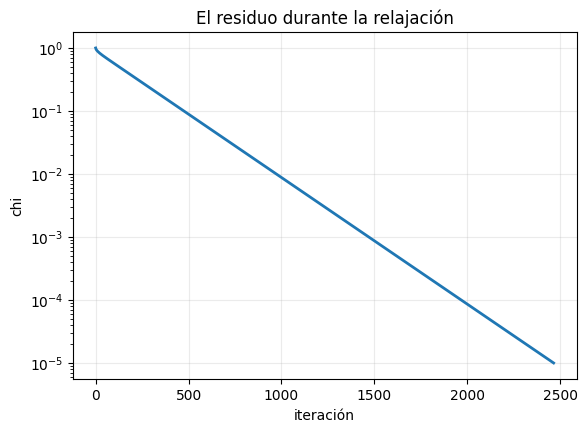

iteraciones ejecutadas = 2466 de 2500
chi inicial = 1.000
chi final = 9.973e-06


In [66]:
def resolver_reposo(a=1.0, b=1.0, E=2.0, nu=1 / 3, rho_g=1.0,
                    n=21, pasos=2500, omega=1.0, tolerancia=None):
    x = np.linspace(0.0, a, n)
    y = np.linspace(0.0, b, n)
    X, Y = np.meshgrid(x, y)
    dx = x[1] - x[0]
    dy = y[1] - y[0]

    UX = np.zeros_like(X)
    UY = np.zeros_like(Y)
    UX, UY = imponer_apoyos(UX, UY)

    epsilon = epsilon_relajacion(E, dx, dy, omega)
    escala = max(abs(rho_g), 1.0)
    historia = []

    for paso in range(pasos):
        RX, RY = residuo_equilibrio(UX, UY, dx, dy, E, nu, rho_g)
        chi = norma_residuo(RX, RY, escala)
        historia.append(chi)

        if tolerancia is not None and chi <= tolerancia:
            break

        UX, UY = paso_relajacion(
            UX, UY, dx, dy, E, nu, rho_g, epsilon
        )

    return X, Y, UX, UY, np.array(historia)


Xr, Yr, UXr, UYr, historia = resolver_reposo(
    a=a, b=b, E=E, nu=nu, rho_g=rho_g,
    n=n, pasos=nsteps, omega=omega, tolerancia=1e-5
)

fig, ax = plt.subplots()
ax.semilogy(historia, color='tab:blue', lw=2)
ax.set(xlabel='iteración', ylabel='chi', title='El residuo durante la relajación')
plt.show()

print(f'iteraciones ejecutadas = {len(historia)} de {nsteps}')
print(f'chi inicial = {historia[0]:.3f}')
print(f'chi final = {historia[-1]:.3e}')

## 11. Hacer visible la deformación

Para mirar el campo dibujamos

$$
(x,y)+s(u_x,u_y).
$$

La escala $s$ es solo gráfica: no cambia la solución física. Si elegimos una escala demasiado grande, una malla correcta puede parecer que atraviesa el piso. Por eso usaremos una escala moderada y dibujaremos explícitamente la línea $y=0$.

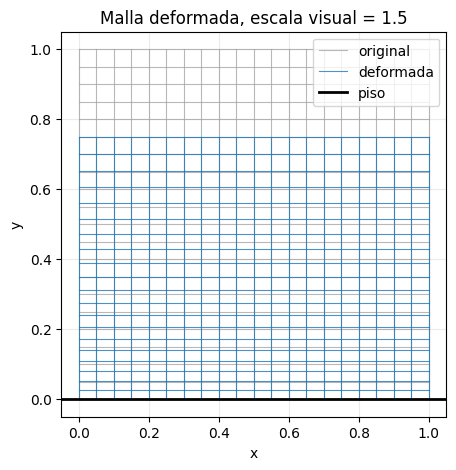

máximo |u|: 0.16666475767513284


In [67]:
def dibujar_malla_deformada(
    ax, X, Y, UX, UY, escala=1.0, color='tab:blue', label=None
):
    Xd = X + escala * UX
    Yd = Y + escala * UY

    # Etiquetamos una sola curva para que la leyenda no se repita.
    for j in range(X.shape[0]):
        etiqueta = label if j == 0 else None
        ax.plot(Xd[j, :], Yd[j, :],
                color=color, lw=0.8, alpha=0.8, label=etiqueta)

    for i in range(X.shape[1]):
        ax.plot(Xd[:, i], Yd[:, i],
                color=color, lw=0.8, alpha=0.8)


fig, ax = plt.subplots(figsize=(6, 5))
dibujar_malla_deformada(
    ax, X, Y, np.zeros_like(X), np.zeros_like(Y),
    escala=1.0, color='0.65', label='original'
)
dibujar_malla_deformada(
    ax, Xr, Yr, UXr, UYr,
    escala=visual_scale, color='tab:blue', label='deformada'
)
ax.axhline(0.0, color='k', lw=2.0, label='piso')
ax.set(
    xlabel='x',
    ylabel='y',
    title=f'Malla deformada, escala visual = {visual_scale:g}'
)
ax.set_aspect('equal')
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='best')
plt.show()

print('máximo |u|:', np.max(np.sqrt(UXr ** 2 + UYr ** 2)))

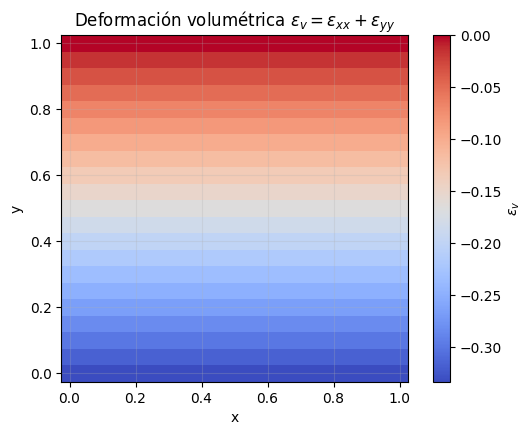

In [68]:
UXX, UYY, UXY = deformacion(UXr, UYr, dx, dy)

# Para este ejemplo mostraremos el cambio volumétrico lineal.
# En deformación plana, epsilon_zz = 0, así que
# epsilon_v = epsilon_xx + epsilon_yy.
deformacion_volumetrica = UXX + UYY

fig, ax = plt.subplots()
imagen = ax.pcolormesh(
    Xr, Yr, deformacion_volumetrica,
    shading='auto', cmap='coolwarm'
)
ax.set(
    xlabel='x',
    ylabel='y',
    title='Deformación volumétrica $\\varepsilon_v=\\varepsilon_{xx}+\\varepsilon_{yy}$'
)
ax.set_aspect('equal')
fig.colorbar(imagen, ax=ax, label='$\\varepsilon_v$')
plt.show()

## 12. Comparar con la referencia analítica

La solución numérica vive en todos los nodos. Para compararla con la solución 1D tomamos la columna central y observamos $u_y(y)$.

Ahora la comparación sí es una prueba útil: la condición de tracción superior se impone con una aproximación de segundo orden y la relajación continúa hasta que el residuo interior es pequeño.

Esperamos que

$$
\chi\longrightarrow 0,
\qquad
\left|u_y^{\mathrm{num}}-u_y^{\mathrm{analítica}}\right|
\longrightarrow 0.
$$

Una diferencia pequeña no significa que ambos métodos usen exactamente las mismas operaciones: la curva analítica es continua y la solución numérica vive en una malla.

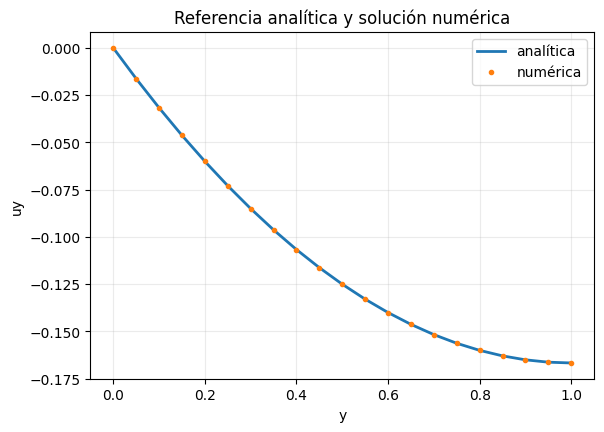

error máximo en la columna central = 1.909e-06
chi final = 9.973e-06


In [69]:
uy_numerico = UYr[:, n // 2]

fig, ax = plt.subplots()
ax.plot(y, uy_analitico, color='tab:blue', lw=2,
        label='analítica')
ax.plot(y, uy_numerico, 'o', ms=3, color='tab:orange',
        label='numérica')
ax.set(xlabel='y', ylabel='uy', title='Referencia analítica y solución numérica')
ax.legend()
plt.show()

error_central = np.max(np.abs(uy_numerico - uy_analitico))
print(f'error máximo en la columna central = {error_central:.3e}')
print(f'chi final = {historia[-1]:.3e}')

## 13. Explorar con sliders

Los sliders convierten predicciones cualitativas en preguntas observables: ¿qué hace la rigidez?, ¿qué cambia al modificar $\nu$?, ¿cuánto tarda en bajar el residuo?

La malla es pequeña para que cada exploración sea rápida. Si ipywidgets no está instalado, el resto del notebook sigue funcionando.

In [70]:
try:
    import ipywidgets as widgets
    from IPython.display import display
    widgets_disponibles = True
except ImportError:
    widgets_disponibles = False
    print('Para activar sliders: instala ipywidgets en el entorno del notebook.')


def vista_interactiva(E_slider=2.0, nu_slider=0.33, rho_slider=1.0,
                      pasos=250, escala=1.5):
    Xv, Yv, UXv, UYv, hv = resolver_reposo(
        E=E_slider, nu=nu_slider, rho_g=rho_slider,
        n=21, pasos=int(pasos), omega=1.0
    )

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    axes[0].semilogy(hv, color='tab:blue')
    axes[0].set(xlabel='iteración', ylabel='chi', title='Residuo')

    dibujar_malla_deformada(
        axes[1], Xv, Yv, np.zeros_like(Xv), np.zeros_like(Yv),
        escala=1.0, color='0.7', label='original'
    )
    dibujar_malla_deformada(
        axes[1], Xv, Yv, UXv, UYv,
        escala=escala, color='tab:blue', label='deformada'
    )
    axes[1].axhline(0.0, color='k', lw=2.0, label='piso')
    axes[1].set(
        xlabel='x',
        ylabel='y',
        title=f'E={E_slider:.2f}, nu={nu_slider:.2f}'
    )
    axes[1].set_aspect('equal')
    axes[1].set_ylim(-0.05, 1.05)
    axes[1].legend(loc='best')
    plt.show()


if widgets_disponibles:
    display(widgets.interactive(
        vista_interactiva,
        E_slider=widgets.FloatSlider(value=2.0, min=0.5, max=6.0, step=0.5),
        nu_slider=widgets.FloatSlider(value=0.33, min=0.0, max=0.45, step=0.01),
        rho_slider=widgets.FloatSlider(value=1.0, min=0.0, max=2.0, step=0.1),
        pasos=widgets.IntSlider(value=250, min=50, max=600, step=50),
        escala=widgets.FloatSlider(value=1.5, min=0.5, max=3.0, step=0.5),
    ))

interactive(children=(FloatSlider(value=2.0, description='E_slider', max=6.0, min=0.5, step=0.5), FloatSlider(…

## 14. Retos de comprobación

Responde ejecutando las celdas, no solo mentalmente:

- **Reto A — rigidez frente a peso.** Cambia $E$ y comprueba si disminuye el desplazamiento.
- **Reto B — resolución.** Compara $n=11$, $21$ y $31$ usando el mismo número de pasos. ¿Qué cambia en $\chi$ y en $|u|$?
- **Reto C — fuerza de cuerpo.** Pon $\rho_g=0$ y verifica que el campo inicial permanece en reposo.

Las respuestas numéricas están en la celda siguiente, marcada como solución oculta.

In [71]:
E_reto = 4.0
_, _, UX_reto, UY_reto, hist_reto = resolver_reposo(
    E=E_reto, nu=nu, rho_g=rho_g, n=21, pasos=400
)
print('max |u| con E=4:', np.max(np.sqrt(UX_reto ** 2 + UY_reto ** 2)))

for n_reto in [11, 21, 31]:
    _, _, UXg, UYg, histg = resolver_reposo(
        E=E, nu=nu, rho_g=rho_g, n=n_reto, pasos=300
    )
    print(f'n={n_reto:2d}, chi final={histg[-1]:.3e}, '
          f'max |u|={np.max(np.sqrt(UXg ** 2 + UYg ** 2)):.3e}')

_, _, UX0, UY0, hist0 = resolver_reposo(
    E=E, nu=nu, rho_g=0.0, n=21, pasos=50
)
print('max |u| sin gravedad:', np.max(np.abs([UX0, UY0])))
print('chi sin gravedad:', hist0[-1])

max |u| con E=4: 0.06982817960714971
n=11, chi final=3.490e-03, max |u|=1.660e-01
n=21, chi final=2.252e-01, max |u|=1.238e-01
n=31, chi final=4.864e-01, max |u|=7.388e-02
max |u| sin gravedad: 0.0
chi sin gravedad: 0.0


## 15. Reto-tarea: una gelatina apoyada solo en el piso

Ahora imaginemos una gelatina sobre una mesa, sin paredes laterales.

El problema tiene:

- piso impermeable: $u_y=0$ en $y=0$;
- deslizamiento horizontal libre sobre el piso: $\sigma_{xy}=0$ en $y=0$;
- paredes laterales libres: $\boldsymbol{\sigma}\mathbf n=\mathbf 0$;
- superficie superior libre: $\boldsymbol{\sigma}\mathbf n=\mathbf 0$.

La tarea es analizar cómo se asienta y cómo se expande lateralmente. Antes de revelar el desarrollo, intenta decidir qué condiciones deben cambiar respecto al bloque encerrado.

Hay una sutileza numérica: como no hay paredes que fijen la posición horizontal, una traslación rígida en $x$ no cambia los esfuerzos. Fijaremos un solo nodo horizontal como referencia numérica; esto no representa una pared ni una fuerza adicional.

Las celdas de solución están marcadas como ocultas. Al final mostraremos la malla deformada y los campos más informativos.

### Qué cambia respecto al bloque encerrado

En el problema anterior imponíamos $u_x=0$ en las dos paredes. Aquí eliminamos esas dos condiciones.

La frontera inferior es mixta:

$$
u_y=0,
\qquad
\sigma_{xy}=0
\qquad
\text{en } y=0.
$$

La primera condición impide que la gelatina atraviese el piso. La segunda permite que se deslice horizontalmente sin fricción.

En las paredes laterales usamos, con normales horizontales,

$$
\sigma_{xx}=0,
\qquad
\sigma_{xy}=0.
$$

En la superficie superior usamos

$$
\sigma_{xy}=0,
\qquad
\sigma_{yy}=0.
$$

La densidad $\rho$ es un dato del material y la gravedad usa $\rho g$. Como aquí es uniforme, no aporta información espacial nueva en una figura; la reportaremos como entrada, pero no la dibujaremos como si fuera un resultado.

In [72]:
def imponer_solo_piso(UX, UY):
    # Impone la no penetración vertical y fija una referencia horizontal.
    UX_nuevo = UX.copy()
    UY_nuevo = UY.copy()

    # El piso fija la componente normal del desplazamiento.
    UY_nuevo[0, :] = 0.0

    # Solo quitamos la traslación rígida horizontal indeterminada.
    # No representa una pared ni una reacción física.
    UX_nuevo[0, UX.shape[1] // 2] = 0.0

    return UX_nuevo, UY_nuevo


def corregir_fronteras_libres_gelatina(UX, UY, dx, dy, E, nu):
    lam, mu = parametros_lame(E, nu)
    coef = lam / (lam + 2.0 * mu)

    UX = UX.copy()
    UY = UY.copy()

    dUX_dx, dUX_dy = gradientes(UX, dx, dy)
    dUY_dx, dUY_dy = gradientes(UY, dx, dy)

    # Pared izquierda: sigma_xx = sigma_xy = 0.
    objetivo_ux_x = -coef * dUY_dy[:, 0]
    objetivo_uy_x = -dUX_dy[:, 0]
    UX[:, 0] = (
        4.0 * UX[:, 1] - UX[:, 2]
        - 2.0 * dx * objetivo_ux_x
    ) / 3.0
    UY[:, 0] = (
        4.0 * UY[:, 1] - UY[:, 2]
        - 2.0 * dx * objetivo_uy_x
    ) / 3.0

    # Pared derecha: mismas dos condiciones, con derivada hacia +x.
    objetivo_ux_x = -coef * dUY_dy[:, -1]
    objetivo_uy_x = -dUX_dy[:, -1]
    UX[:, -1] = (
        4.0 * UX[:, -2] - UX[:, -3]
        + 2.0 * dx * objetivo_ux_x
    ) / 3.0
    UY[:, -1] = (
        4.0 * UY[:, -2] - UY[:, -3]
        + 2.0 * dx * objetivo_uy_x
    ) / 3.0

    # Superficie superior: sigma_xy = sigma_yy = 0.
    dUX_dx, dUX_dy = gradientes(UX, dx, dy)
    dUY_dx, dUY_dy = gradientes(UY, dx, dy)
    objetivo_ux_y = -dUY_dx[-1, :]
    objetivo_uy_y = -coef * dUX_dx[-1, :]
    UX[-1, :] = (
        4.0 * UX[-2, :] - UX[-3, :]
        + 2.0 * dy * objetivo_ux_y
    ) / 3.0
    UY[-1, :] = (
        4.0 * UY[-2, :] - UY[-3, :]
        + 2.0 * dy * objetivo_uy_y
    ) / 3.0

    # Piso: uy está prescrito y sigma_xy = 0.
    dUX_dx, dUX_dy = gradientes(UX, dx, dy)
    dUY_dx, dUY_dy = gradientes(UY, dx, dy)
    objetivo_ux_y = -dUY_dx[0, :]
    UX[0, :] = (
        4.0 * UX[1, :] - UX[2, :]
        - 2.0 * dy * objetivo_ux_y
    ) / 3.0

    return imponer_solo_piso(UX, UY)

In [73]:
def paso_gelatina(UX, UY, dx, dy, E, nu, rho_g, epsilon):
    RX, RY = residuo_equilibrio(UX, UY, dx, dy, E, nu, rho_g)

    UX_nuevo = UX.copy()
    UY_nuevo = UY.copy()

    # El residuo actualiza solo el interior.
    interior = np.s_[1:-1, 1:-1]
    UX_nuevo[interior] += epsilon * RX[interior]
    UY_nuevo[interior] += epsilon * RY[interior]

    # Las fronteras libres se reconstruyen usando sigma n = 0.
    return corregir_fronteras_libres_gelatina(
        UX_nuevo, UY_nuevo, dx, dy, E, nu
    )


def resolver_gelatina(a=1.0, b=1.0, E=2.0, nu=1 / 3,
                      rho_g=1.0, n=21, pasos=3000,
                      omega=1.0, tolerancia=2e-4):
    xg = np.linspace(0.0, a, n)
    yg = np.linspace(0.0, b, n)
    Xg, Yg = np.meshgrid(xg, yg)
    dxg = xg[1] - xg[0]
    dyg = yg[1] - yg[0]

    UXg = np.zeros_like(Xg)
    UYg = np.zeros_like(Yg)
    UXg, UYg = imponer_solo_piso(UXg, UYg)

    epsilon_g = epsilon_relajacion(E, dxg, dyg, omega)
    escala = max(abs(rho_g), 1.0)
    historia_g = []

    for paso in range(pasos):
        RXg, RYg = residuo_equilibrio(
            UXg, UYg, dxg, dyg, E, nu, rho_g
        )
        chi_g = norma_residuo(RXg, RYg, escala)
        historia_g.append(chi_g)

        if tolerancia is not None and chi_g <= tolerancia:
            break

        UXg, UYg = paso_gelatina(
            UXg, UYg, dxg, dyg, E, nu, rho_g, epsilon_g
        )

    return Xg, Yg, UXg, UYg, np.array(historia_g)

In [74]:
Xg, Yg, UXg, UYg, historia_g = resolver_gelatina(
    a=a, b=b, E=E, nu=nu, rho_g=rho_g,
    n=21, pasos=3000, omega=omega, tolerancia=2e-4
)

dxg = Xg[0, 1] - Xg[0, 0]
dyg = Yg[1, 0] - Yg[0, 0]

SXXg, SYYg, SXYg = esfuerzo(UXg, UYg, dxg, dyg, E, nu)

traccion_izquierda = np.sqrt(SXXg[:, 0]**2 + SXYg[:, 0]**2)
traccion_derecha = np.sqrt(SXXg[:, -1]**2 + SXYg[:, -1]**2)
traccion_superior = np.sqrt(SXYg[-1, :]**2 + SYYg[-1, :]**2)
traccion_piso = np.abs(SXYg[0, :])

print(f'iteraciones de la gelatina: {len(historia_g)}')
print(f'chi inicial = {historia_g[0]:.3e}')
print(f'chi final = {historia_g[-1]:.3e}')
print(f'tracción máxima pared izquierda = {traccion_izquierda.max():.3e}')
print(f'tracción máxima pared derecha = {traccion_derecha.max():.3e}')
print(f'tracción máxima superficie superior = {traccion_superior.max():.3e}')
print(f'tracción tangencial máxima en el piso = {traccion_piso.max():.3e}')
print(f'densidad prescrita rho = {rho:.3f}')

iteraciones de la gelatina: 2523
chi inicial = 1.000e+00
chi final = 1.998e-04
tracción máxima pared izquierda = 2.978e-01
tracción máxima pared derecha = 2.978e-01
tracción máxima superficie superior = 1.555e-01
tracción tangencial máxima en el piso = 4.398e-15
densidad prescrita rho = 1.000


### Campos que vamos a visualizar

Para la gelatina mostraremos:

- $u_x$ y $u_y$, las componentes del desplazamiento;
- $|\mathbf u|$, la magnitud del desplazamiento;
- la deformación volumétrica;
- la presión media compresiva;
- $\sigma_{xx}$, $\sigma_{yy}$ y $\sigma_{xy}$.

No dibujaremos $\rho$: en este ejemplo es uniforme y fue prescrita, así que su figura sería una mancha constante sin información adicional. Tampoco repetiremos $\sigma_{yy}$ entre los campos generales y la figura final de esfuerzos.

Usaremos la convención de que una presión positiva representa compresión:

$$
p
=
-
\frac{\sigma_{xx}+\sigma_{yy}+\sigma_{zz}}{3}.
$$

Como el modelo es de deformación plana, $\varepsilon_{zz}=0$ y

$$
\sigma_{zz}
=
\lambda(\varepsilon_{xx}+\varepsilon_{yy}).
$$

La deformación volumétrica lineal que mostraremos es

$$
\varepsilon_v=\varepsilon_{xx}+\varepsilon_{yy}.
$$

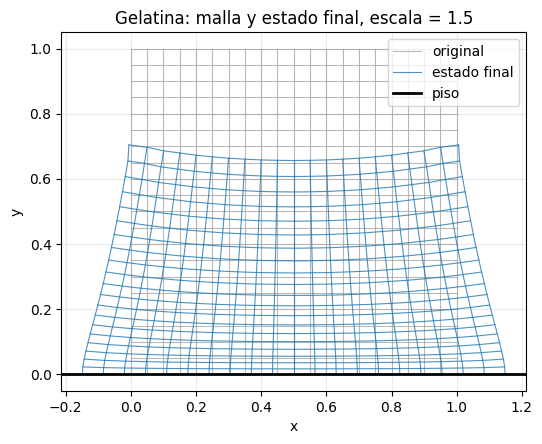

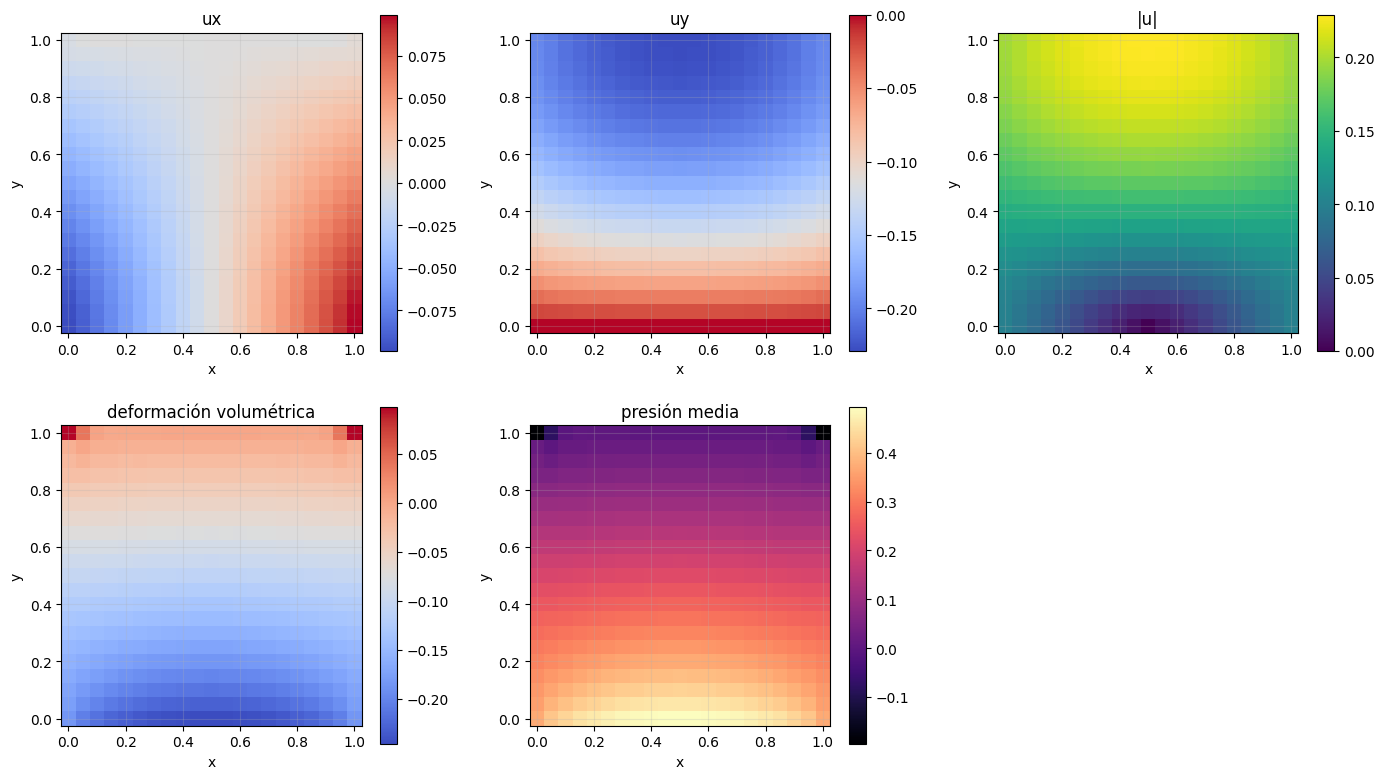

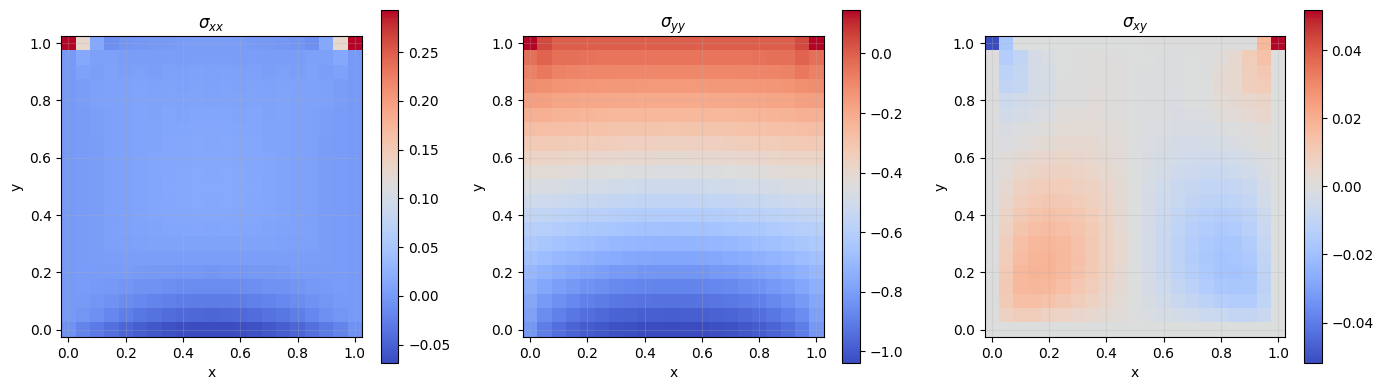

In [75]:
UXXg, UYYg, UXYg = deformacion(UXg, UYg, dxg, dyg)
lam_g, mu_g = parametros_lame(E, nu)

SZZg = lam_g * (UXXg + UYYg)
presion_g = -(SXXg + SYYg + SZZg) / 3.0
deformacion_volumetrica_g = UXXg + UYYg
magnitud_u_g = np.sqrt(UXg**2 + UYg**2)

# Primero mostramos la malla y el estado final.
fig, ax = plt.subplots(figsize=(6, 5))
dibujar_malla_deformada(
    ax, Xg, Yg, np.zeros_like(Xg), np.zeros_like(Yg),
    escala=1.0, color='0.65', label='original'
)
dibujar_malla_deformada(
    ax, Xg, Yg, UXg, UYg,
    escala=visual_scale, color='tab:blue', label='estado final'
)
ax.axhline(0.0, color='k', lw=2.0, label='piso')
ax.set(
    xlabel='x',
    ylabel='y',
    title=f'Gelatina: malla y estado final, escala = {visual_scale:g}'
)
ax.set_aspect('equal')
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='best')
plt.show()

campos = [
    (UXg, 'ux', 'coolwarm'),
    (UYg, 'uy', 'coolwarm'),
    (magnitud_u_g, '|u|', 'viridis'),
    (deformacion_volumetrica_g, 'deformación volumétrica', 'coolwarm'),
    (presion_g, 'presión media', 'magma'),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, (campo, titulo, mapa) in zip(axes.flat, campos):
    imagen = ax.pcolormesh(Xg, Yg, campo, shading='auto', cmap=mapa)
    ax.set(xlabel='x', ylabel='y', title=titulo)
    ax.set_aspect('equal')
    fig.colorbar(imagen, ax=ax)

axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, campo, titulo in zip(
    axes,
    [SXXg, SYYg, SXYg],
    [r'$\sigma_{xx}$', r'$\sigma_{yy}$', r'$\sigma_{xy}$']
):
    imagen = ax.pcolormesh(Xg, Yg, campo, shading='auto', cmap='coolwarm')
    ax.set(xlabel='x', ylabel='y', title=titulo)
    ax.set_aspect('equal')
    fig.colorbar(imagen, ax=ax)

plt.tight_layout()
plt.show()

### Cómo leer el resultado

La malla final permite comprobar directamente que:

- el piso conserva $u_y=0$;
- la gelatina se asienta verticalmente;
- al no haber paredes laterales, puede expandirse horizontalmente;
- la escala visual no debe confundirse con un movimiento físico real.

La densidad solo aparece como dato de entrada: $\rho$ es uniforme y por eso no necesitamos una figura para ella. La presión, la deformación volumétrica y los esfuerzos son los campos calculados que ayudan a interpretar el estado final.

Las tracciones impresas son diagnósticos de las fronteras libres; el residuo interior $\chi$ y las tracciones de borde no son exactamente la misma medida.